#PREPARACIÓN DE LA BASE DE DATOS
Se prepara a la base de datos identificando a las víctimas y se configura el proxy de femicidio para su posterior análisis.

In [2]:
# Base de datos desde GitHub
import pandas as pd

url = "https://github.com/valengilgodoy8/hackaton-ask/blob/main/HomicidiosDolosos.xlsx?raw=true"

import numpy as np
import os

# Cargar en el DataFrame
df = pd.read_excel(url)
print(df.head())
print(df.info())

# Ordenamos: cada hecho tiene una fila por víctima y una fila por imputado,
# nos quedamos sólo con la fila de víctimas, nuevo df se llama "vic".
vic = df[df['tipo_persona'] == 'Víctima'].copy()

# Definimos femicidio como proxy, usamos (tipo_hecho_segun_victima),
# incluyendo tanto los casos confirmados como los "posibles".

LABELS_FEMICIDIO = [
    'HD Mujer Cis Trans Travesti-Femicidio',
    'HD Mujer Cis Trans Travesti-Femicidio vinculado',
    'HD Mujer Cis Trans Travesti-Posible femicidio',
    'HD Mujer Cis Trans Travesti-Posible femicidio vinculado',
]
vic['es_femicidio_proxy'] = vic['tipo_hecho_segun_victima'].isin(LABELS_FEMICIDIO)

# Se crea una nueva columna en el DataFrame vic llamada 'es_femicidio_proxy', que es un valor booleano (True/False)
# indicando si el valor en la columna 'tipo_hecho_segun_victima' de cada fila
# está presente en la lista LABELS_FEMICIDIO.

vic['grupo'] = np.select(
    [
        vic['es_femicidio_proxy'],
        vic['tipo_hecho_segun_victima'].isin(['HD Varón', 'HD Varón-Femicidio vinculado'])
    ],
    ['Femicidio (proxy amplio)', 'Homicidio de varón'],
    default='Otro / sin clasificar'
)
print(vic['grupo'].value_counts())

# Grupo de comparación binaria: agregamos los homicidios de varón como
# contraparte del proxy de femicidio, para poder comparar ambos perfiles.
vic['grupo'] = np.select(
    [
        vic['es_femicidio_proxy'],
        vic['tipo_hecho_segun_victima'].isin(['HD Varón', 'HD Varón-Femicidio vinculado'])
    ],
    ['Femicidio (proxy amplio)', 'Homicidio de varón'],
    default='Otro / sin clasificar'
)

print(vic['grupo'].value_counts())
print(f"\nTotal de víctimas: {len(vic)}")

# A partir de acá trabajamos solo con los dos grupos de interés
comp = vic[vic['grupo'].isin(['Femicidio (proxy amplio)', 'Homicidio de varón'])].copy()


   id_hecho tipo_hecho_segun_victima            tipo_persona_id tipo_persona  \
0     11535                 HD Varón   Víctima idRegistro 12235      Víctima   
1     11535                 HD Varón  Imputado idRegistro 12929     Imputado   
2     11535                 HD Varón  Imputado idRegistro 12931     Imputado   
3     11535                 HD Varón  Imputado idRegistro 12930     Imputado   
4     11536                 HD Varón  Imputado idRegistro 12933     Imputado   

   cant_inc  cant_vic federal  provincia_id provincia_nombre  departamento_id  \
0         3         1      No            58          Neuquén            58035   
1         3         1      No            58          Neuquén            58035   
2         3         1      No            58          Neuquén            58035   
3         3         1      No            58          Neuquén            58035   
4         2         1      No            58          Neuquén            58035   

   ... victi_situacion_ocupacion

#ANÁLISIS EXPLORATORIO DE LOS DATOS
Se analizarán patrones de ocurrencia, perfil del agresor y distribución en el tiempo de los crímenes.

Cantidad de casos por año:
grupo  Femicidio (proxy amplio)  Homicidio de varón
anio                                               
2017                        285                1871
2018                        269                1963
2019                        278                1862
2020                        270                2021
2021                        226                1768
2022                        251                1588
2023                        238                1662
2024                        235                1467

Evolución indexada (2017 = 100):
grupo  Femicidio (proxy amplio)  Homicidio de varón
anio                                               
2017                      100.0               100.0
2018                       94.4               104.9
2019                       97.5                99.5
2020                       94.7               108.0
2021                       79.3                94.5
2022                       88.1                84.9
202

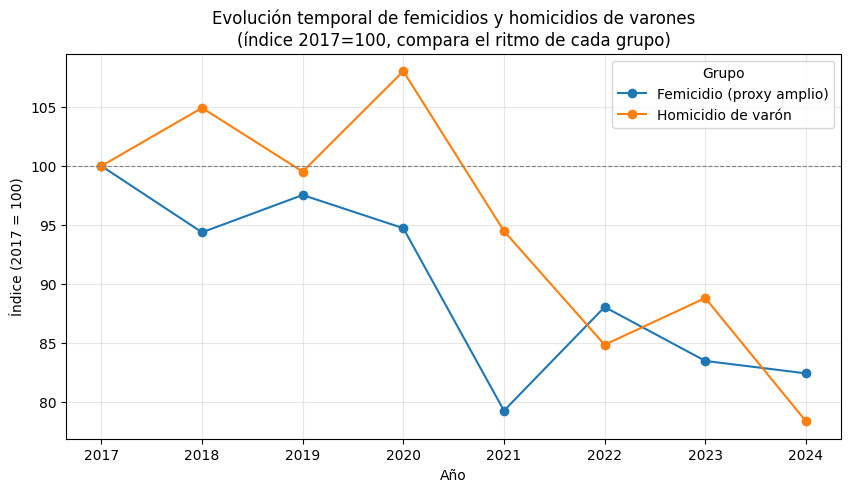

In [ ]:
# EVOLUCIÓN TEMPORAL (2017-2024)

# Importamos la librería para realizar gráficos
import matplotlib.pyplot as plt

# Contamos la cantidad de casos por año para cada grupo
evolucion = pd.crosstab(
    comp['anio'],
    comp['grupo']
)

print("Cantidad de casos por año:")
print(evolucion)

# NOTA: los homicidios de varón superan a los femicidios en una proporción
# ~7:1. Si graficamos los conteos absolutos tal cual, la línea de femicidios
# queda aplastada contra el eje X y no se puede ver su propia tendencia.
# Por eso indexamos cada serie a su propio valor de 2017 (=100): así
# comparamos el RITMO de cada grupo, sin que el volumen tape nada.
evolucion_indexada = evolucion / evolucion.iloc[0] * 100

print("\nEvolución indexada (2017 = 100):")
print(evolucion_indexada.round(1))

# Graficamos la evolución temporal indexada
evolucion_indexada.plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)

# Línea de referencia: 100 = mismo nivel que en 2017
plt.axhline(100, color='grey', lw=0.8, linestyle='--')

# Agregamos títulos y nombres de ejes
plt.title('Evolución temporal de femicidios y homicidios de varones\n(índice 2017=100, compara el ritmo de cada grupo)')
plt.xlabel('Año')
plt.ylabel('Índice (2017 = 100)')

# Agregamos una grilla para facilitar la lectura
plt.grid(alpha=0.3)

# Mostramos la referencia de cada grupo
plt.legend(title='Grupo')

# Mostramos el gráfico
plt.show()

Promedio de casos por mes (2017-2024):
grupo  Femicidio (proxy amplio)  Homicidio de varón
mes                                                
1                          23.8               175.9
2                          25.9               153.9
3                          21.1               160.6
4                          19.5               136.8
5                          18.8               131.6
6                          19.1               131.2
7                          19.4               135.6
8                          18.1               147.8
9                          20.8               138.8
10                         23.4               148.8
11                         20.4               150.0
12                         26.4               164.4


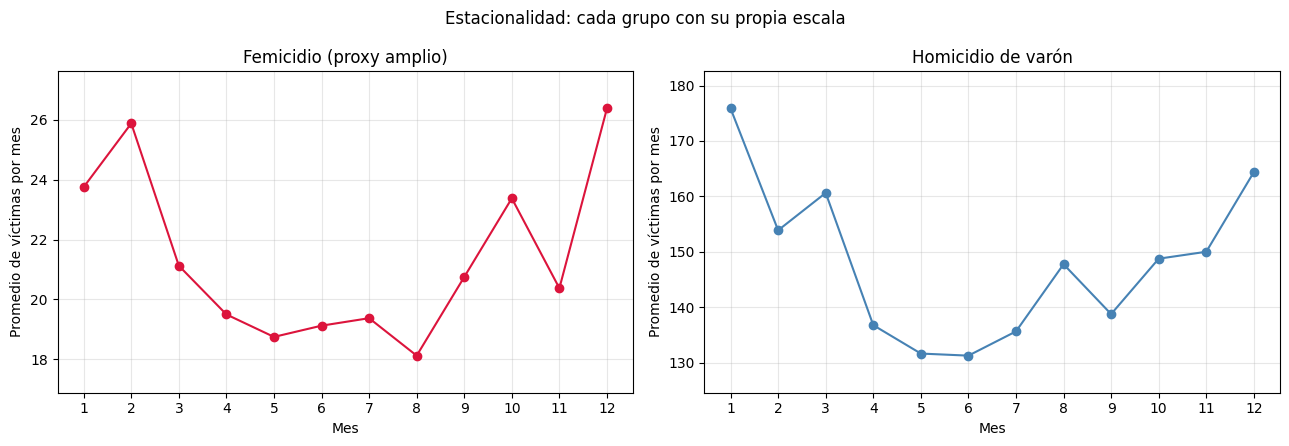

Chi-cuadrado bondad de ajuste (Femicidio vs. uniforme): chi2=32.33  p=0.0007
Chi-cuadrado bondad de ajuste (Homicidio de varón vs. uniforme): chi2=116.68  p=0.0000


In [ ]:
# ESTACIONALIDAD (variación a lo largo de los meses %)

estacionalidad = pd.crosstab(
    comp['mes'],
    comp['grupo']
)

cantidad_anios = comp['anio'].nunique()
estacionalidad_promedio = estacionalidad / cantidad_anios

print("Promedio de casos por mes (2017-2024):")
print(estacionalidad_promedio.round(1))

# Un panel por grupo, cada uno con su propia escala: así se ve la forma de
# la curva de cada serie sin que la desproporción de volumen (~7:1) la tape.
colores = {'Femicidio (proxy amplio)': 'crimson', 'Homicidio de varón': 'steelblue'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, estacionalidad_promedio.columns):
    estacionalidad_promedio[col].plot(ax=ax, marker='o', color=colores[col])
    ax.set_title(col)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Promedio de víctimas por mes')
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.3)
    ymin, ymax = estacionalidad_promedio[col].min(), estacionalidad_promedio[col].max()
    margen = (ymax - ymin) * 0.15
    ax.set_ylim(ymin - margen, ymax + margen)

plt.suptitle('Estacionalidad: cada grupo con su propia escala')
plt.tight_layout()
plt.show()

#Test estadístico Chi-cuadrado de bondad de ajuste ---
from scipy import stats

# ¿La distribución mensual de cada grupo difiere de un reparto uniforme
# (mismo % esperado cada uno de los 12 meses)?
obs_fem = estacionalidad['Femicidio (proxy amplio)'].values
esperado_fem = np.full(12, obs_fem.sum() / 12)
chi2_fem, p_fem = stats.chisquare(obs_fem, esperado_fem)
print(f"Chi-cuadrado bondad de ajuste (Femicidio vs. uniforme): chi2={chi2_fem:.2f}  p={p_fem:.4f}")

obs_var = estacionalidad['Homicidio de varón'].values
esperado_var = np.full(12, obs_var.sum() / 12)
chi2_var, p_var = stats.chisquare(obs_var, esperado_var)
print(f"Chi-cuadrado bondad de ajuste (Homicidio de varón vs. uniforme): chi2={chi2_var:.2f}  p={p_var:.4f}")

Cantidad de casos según lugar de ocurrencia:
tipo_lugar                Comercio  Cárcel o comisaría  Domicilio particular  \
grupo                                                                          
Femicidio (proxy amplio)        19                   2                  1329   
Homicidio de varón             336                 148                  3316   

tipo_lugar                Interior de rodados  Otro lugar  Sin determinar  \
grupo                                                                       
Femicidio (proxy amplio)                   14         130             179   
Homicidio de varón                        236         499            1267   

tipo_lugar                Vía pública  
grupo                                  
Femicidio (proxy amplio)          379  
Homicidio de varón               8400  

Porcentaje de casos según lugar de ocurrencia:
tipo_lugar                Comercio  Cárcel o comisaría  Domicilio particular  \
grupo                                

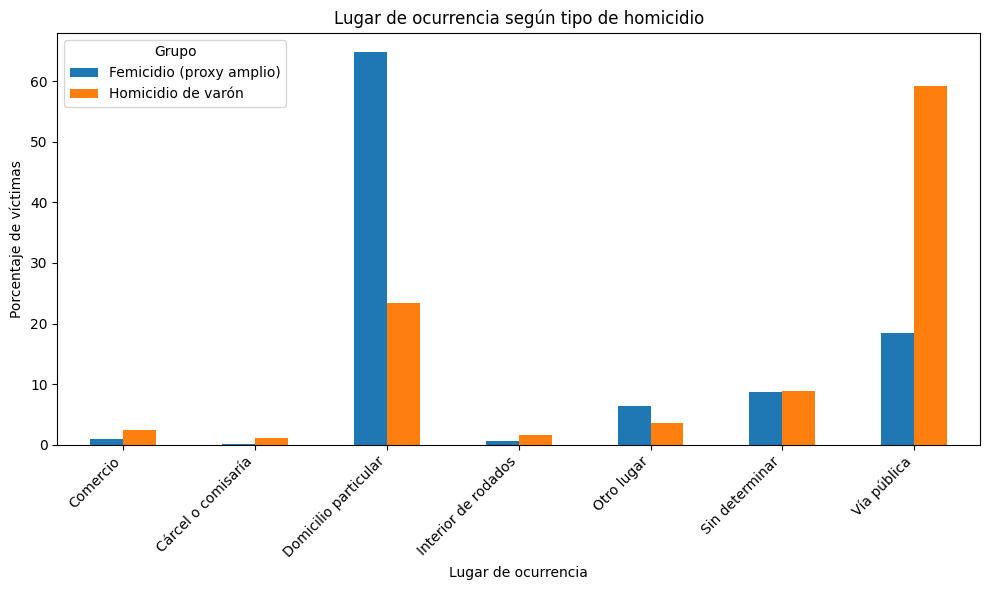


Resultado del test Chi-cuadrado:
Chi-cuadrado: 1707.99
Grados de libertad: 6
P-valor: 0.0
Existe una asociación estadísticamente significativa entre el grupo y el lugar de ocurrencia.


In [ ]:
#LUGAR DE OCURRENCIA

# Importamos la función para realizar el test Chi-cuadrado
from scipy.stats import chi2_contingency

# Creamos una tabla de contingencia para observar
# la cantidad de casos según grupo y lugar de ocurrencia
tabla_lugar = pd.crosstab(
    comp['grupo'],
    comp['tipo_lugar']
)

print("Cantidad de casos según lugar de ocurrencia:")
print(tabla_lugar)

# Calculamos los porcentajes dentro de cada grupo
# para poder comparar femicidios y homicidios de varones
tabla_lugar_pct = pd.crosstab(
    comp['grupo'],
    comp['tipo_lugar'],
    normalize='index'
) * 100

print("\nPorcentaje de casos según lugar de ocurrencia:")
print(tabla_lugar_pct.round(2))

# Graficamos los porcentajes
tabla_lugar_pct.T.plot(
    kind='bar',
    figsize=(10, 6)
)

# Agregamos títulos y nombres de ejes
plt.title('Lugar de ocurrencia según tipo de homicidio')
plt.xlabel('Lugar de ocurrencia')
plt.ylabel('Porcentaje de víctimas')

# Rotamos las etiquetas para facilitar la lectura
plt.xticks(rotation=45, ha='right')

# Mostramos la referencia de cada grupo
plt.legend(title='Grupo')

# Ajustamos el gráfico
plt.tight_layout()

# Mostramos el gráfico
plt.show()

# TEST CHI-CUADRADO

# El test permite analizar si existe asociación
# entre el tipo de homicidio y el lugar de ocurrencia
chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(tabla_lugar)

print("\nResultado del test Chi-cuadrado:")
print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", grados_libertad)
print("P-valor:", p_valor)

# Interpretamos el resultado utilizando un nivel de significación de 0.05
if p_valor < 0.05:
    print("Existe una asociación estadísticamente significativa entre el grupo y el lugar de ocurrencia.")
else:
    print("No se encontró una asociación estadísticamente significativa entre el grupo y el lugar de ocurrencia.")


Cantidad de casos según vínculo con el agresor:
vinculo_agresor           Cliente / proveedor  Conyuge/ pareja  Empleado  \
grupo                                                                      
Femicidio (proxy amplio)                    5              866         2   
Homicidio de varón                         10              278         8   

vinculo_agresor           Empleador  Ex conyuge / ex pareja  Hermano/a  \
grupo                                                                    
Femicidio (proxy amplio)          4                     351         28   
Homicidio de varón               21                      79        217   

vinculo_agresor           Hijo/a  Otras relaciones no familiares  \
grupo                                                              
Femicidio (proxy amplio)      78                             128   
Homicidio de varón           151                            2684   

vinculo_agresor           Otros vínculos familiares  Padre/Madre  \
grupo    

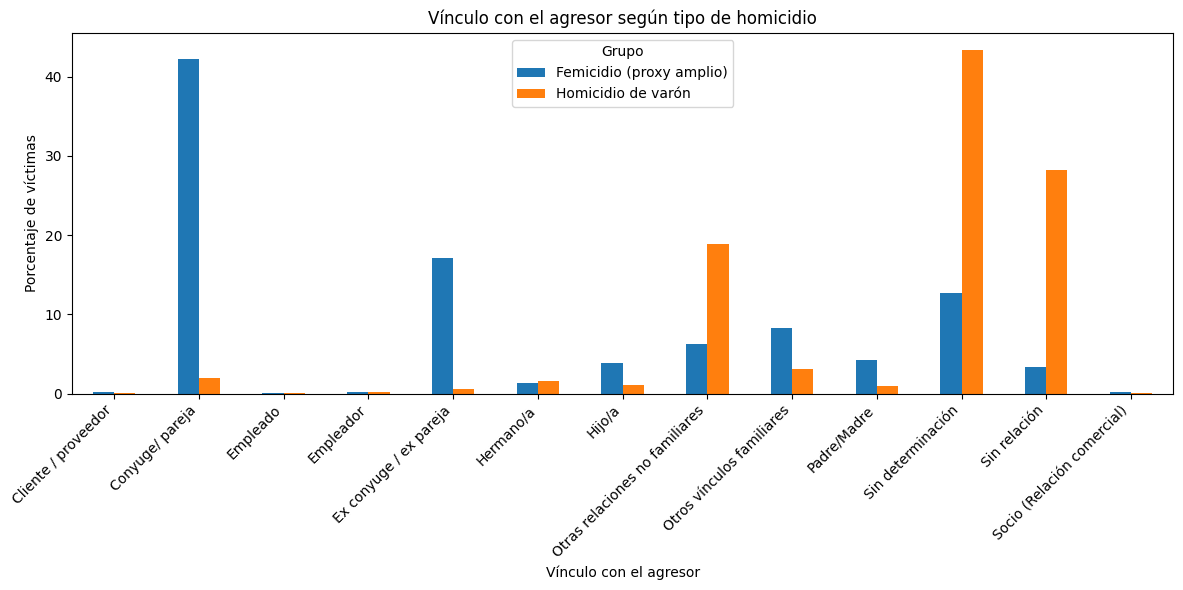


Resultado del test Chi-cuadrado:
Chi-cuadrado: 7396.89
Grados de libertad: 12
P-valor: 0.0
Existe una asociación estadísticamente significativa entre el grupo y el vínculo con el agresor.

Resultado de V de Cramér:
V de Cramér: 0.675
La asociación entre las variables es fuerte.


In [ ]:
# VÍNCULO CON AGRESOR

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Creamos una copia de la variable vínculo para trabajar con ella
# Reemplazamos los valores vacíos por "Sin información"
comp['vinculo_agresor'] = comp['victima_relacion_inculpado'].fillna('Sin información')

# Creamos una tabla de contingencia para observar
# la cantidad de casos según grupo y vínculo con el agresor
tabla_vinculo = pd.crosstab(
    comp['grupo'],
    comp['vinculo_agresor']
)

print("Cantidad de casos según vínculo con el agresor:")
print(tabla_vinculo)

# Calculamos los porcentajes dentro de cada grupo
# para poder comparar femicidios y homicidios de varones
tabla_vinculo_pct = pd.crosstab(
    comp['grupo'],
    comp['vinculo_agresor'],
    normalize='index'
) * 100

print("\nPorcentaje de casos según vínculo con el agresor:")
print(tabla_vinculo_pct.round(2))

# Graficamos los porcentajes
tabla_vinculo_pct.T.plot(
    kind='bar',
    figsize=(12, 6)
)

# Agregamos títulos y nombres de ejes
plt.title('Vínculo con el agresor según tipo de homicidio')
plt.xlabel('Vínculo con el agresor')
plt.ylabel('Porcentaje de víctimas')

# Rotamos las etiquetas para facilitar la lectura
plt.xticks(rotation=45, ha='right')

# Mostramos la referencia de cada grupo
plt.legend(title='Grupo')

# Ajustamos el gráfico
plt.tight_layout()

# Mostramos el gráfico
plt.show()


# TEST CHI-CUADRADO

# El test permite analizar si existe asociación
# entre el tipo de homicidio y el vínculo con el agresor
chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(tabla_vinculo)

print("\nResultado del test Chi-cuadrado:")
print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", grados_libertad)
print("P-valor:", p_valor)

# Interpretamos el resultado utilizando un nivel de significación de 0.05
if p_valor < 0.05:
    print("Existe una asociación estadísticamente significativa entre el grupo y el vínculo con el agresor.")
else:
    print("No se encontró una asociación estadísticamente significativa entre el grupo y el vínculo con el agresor.")


# V DE CRAMÉR - INTENSIDAD DE LA ASOCIACIÓN

# Calculamos la cantidad total de casos
n = tabla_vinculo.to_numpy().sum()

# Obtenemos la cantidad de filas y columnas
filas, columnas = tabla_vinculo.shape

# Calculamos V de Cramér
v_cramer = np.sqrt(
    chi2 / (n * min(filas - 1, columnas - 1))
)

print("\nResultado de V de Cramér:")
print("V de Cramér:", round(v_cramer, 3))

# Interpretamos la intensidad de la asociación
if v_cramer < 0.10:
    print("La asociación entre las variables es muy débil o prácticamente nula.")
elif v_cramer < 0.30:
    print("La asociación entre las variables es débil.")
elif v_cramer < 0.50:
    print("La asociación entre las variables es moderada.")
else:
    print("La asociación entre las variables es fuerte.")


Perfiles de arma y lugar más frecuentes:
perfil_arma_lugar
Arma de fuego | Vía pública                      5483
Arma blanca | Vía pública                        2249
Arma de fuego | Domicilio particular             1691
Arma blanca | Domicilio particular               1503
Arma de fuego | Sin determinar                    731
Arma blanca | Sin determinar                      454
Objeto contundente | Domicilio particular         398
Objeto contundente | Vía pública                  363
Sin determinación | Domicilio particular          331
Golpes | Vía pública                              263
Ahorcamiento / asfixia | Domicilio particular     258
Golpes | Domicilio particular                     257
Arma de fuego | Comercio                          242
Sin determinación | Vía pública                   205
Arma de fuego | Otro lugar                        201
Name: count, dtype: int64

Cantidad de casos según perfil de arma y lugar:
perfil_arma_lugar_agrupado  Ahorcamiento / asfixia | Dom

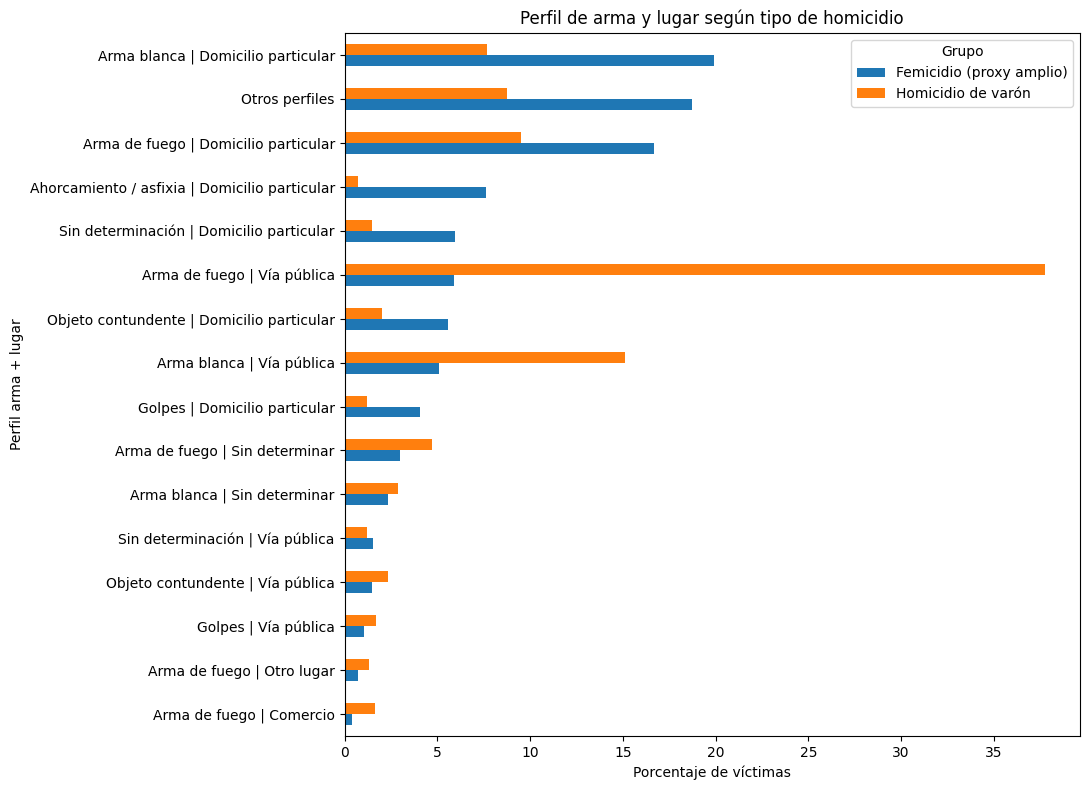


Resultado del test Chi-cuadrado:
Chi-cuadrado: 2179.26
Grados de libertad: 15
P-valor: 0.0
Existe una asociación estadísticamente significativa entre el grupo y el perfil de arma y lugar.

Resultado de V de Cramér:
V de Cramér: 0.366
La asociación entre las variables es moderada.

Control de frecuencias esperadas:
Porcentaje de celdas con frecuencia esperada menor a 5: 0.0 %


In [ ]:
# ASOCIACIÓN ENTRE PERFIL DEL ARMA Y LUGAR

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Creamos una copia de comp para trabajar con arma y lugar
comp_arma_lugar = comp.copy()

# Reemplazamos los valores vacíos por "Sin información"
comp_arma_lugar['clase_arma'] = comp_arma_lugar['clase_arma'].fillna('Sin información')
comp_arma_lugar['tipo_lugar'] = comp_arma_lugar['tipo_lugar'].fillna('Sin información')

# Creamos una nueva variable que combina el arma utilizada
# con el lugar donde ocurrió el hecho
comp_arma_lugar['perfil_arma_lugar'] = (
    comp_arma_lugar['clase_arma'].astype(str)
    + ' | ' +
    comp_arma_lugar['tipo_lugar'].astype(str)
)

# Observamos cuáles son las combinaciones más frecuentes
print("Perfiles de arma y lugar más frecuentes:")
print(
    comp_arma_lugar['perfil_arma_lugar']
    .value_counts()
    .head(15)
)

# Seleccionamos los 15 perfiles más frecuentes
top_perfiles = (
    comp_arma_lugar['perfil_arma_lugar']
    .value_counts()
    .head(15)
    .index
)

# Las combinaciones que no están entre las 15 más frecuentes
# se agrupan dentro de la categoría "Otros perfiles"
comp_arma_lugar['perfil_arma_lugar_agrupado'] = np.where(
    comp_arma_lugar['perfil_arma_lugar'].isin(top_perfiles),
    comp_arma_lugar['perfil_arma_lugar'],
    'Otros perfiles'
)

# Creamos una tabla de contingencia para observar
# la cantidad de casos según grupo y perfil de arma/lugar
tabla_arma_lugar = pd.crosstab(
    comp_arma_lugar['grupo'],
    comp_arma_lugar['perfil_arma_lugar_agrupado']
)

print("\nCantidad de casos según perfil de arma y lugar:")
print(tabla_arma_lugar)

# Calculamos los porcentajes dentro de cada grupo
# para poder comparar femicidios y homicidios de varones
tabla_arma_lugar_pct = pd.crosstab(
    comp_arma_lugar['grupo'],
    comp_arma_lugar['perfil_arma_lugar_agrupado'],
    normalize='index'
) * 100

print("\nPorcentaje de casos según perfil de arma y lugar:")
print(tabla_arma_lugar_pct.round(2))

# Ordenamos los perfiles según su frecuencia
orden_perfiles = (
    tabla_arma_lugar_pct
    .loc['Femicidio (proxy amplio)']
    .sort_values(ascending=True)
    .index
)

tabla_arma_lugar_pct = tabla_arma_lugar_pct[orden_perfiles]

# Graficamos los porcentajes
tabla_arma_lugar_pct.T.plot(
    kind='barh',
    figsize=(11, 8)
)

# Agregamos títulos y nombres de ejes
plt.title('Perfil de arma y lugar según tipo de homicidio')
plt.xlabel('Porcentaje de víctimas')
plt.ylabel('Perfil arma + lugar')

# Mostramos la referencia de cada grupo
plt.legend(title='Grupo')

# Ajustamos el gráfico
plt.tight_layout()

# Mostramos el gráfico
plt.show()


# TEST CHI-CUADRADO

# El test permite analizar si existe asociación entre
# el tipo de homicidio y el perfil combinado de arma y lugar
chi2, p_valor, grados_libertad, frecuencias_esperadas = chi2_contingency(
    tabla_arma_lugar
)

print("\nResultado del test Chi-cuadrado:")
print("Chi-cuadrado:", round(chi2, 2))
print("Grados de libertad:", grados_libertad)
print("P-valor:", p_valor)

# Interpretamos el resultado utilizando
# un nivel de significación de 0.05
if p_valor < 0.05:
    print("Existe una asociación estadísticamente significativa entre el grupo y el perfil de arma y lugar.")
else:
    print("No se encontró una asociación estadísticamente significativa entre el grupo y el perfil de arma y lugar.")


# V DE CRAMÉR - INTENSIDAD DE LA ASOCIACIÓN

# Calculamos la cantidad total de casos
n = tabla_arma_lugar.to_numpy().sum()

# Obtenemos la cantidad de filas y columnas
filas, columnas = tabla_arma_lugar.shape

# Calculamos V de Cramér
v_cramer = np.sqrt(
    chi2 / (n * min(filas - 1, columnas - 1))
)

print("\nResultado de V de Cramér:")
print("V de Cramér:", round(v_cramer, 3))

# Interpretamos la intensidad de la asociación
if v_cramer < 0.10:
    print("La asociación entre las variables es muy débil o prácticamente nula.")
elif v_cramer < 0.30:
    print("La asociación entre las variables es débil.")
elif v_cramer < 0.50:
    print("La asociación entre las variables es moderada.")
else:
    print("La asociación entre las variables es fuerte.")


# Verificamos cuántas frecuencias esperadas son menores a 5
# porque esto es importante para evaluar el test Chi-cuadrado
porcentaje_frecuencias_bajas = (
    (frecuencias_esperadas < 5).sum()
    / frecuencias_esperadas.size
) * 100

print("\nControl de frecuencias esperadas:")
print(
    "Porcentaje de celdas con frecuencia esperada menor a 5:",
    round(porcentaje_frecuencias_bajas, 2),
    "%"
)


# CLUSTERING NO SUPERVISADO: TIPOLOGÍAS DE HOMICIDIO
Usamos: MCA (reduce las variables categóricas a coordenadas numéricas) + K-Means.
La idea: darle al modelo las circunstancias del hecho (arma, lugar, vínculo, edad, origen del registro) SIN decirle a qué grupo pertenece cada caso (excluimos a propósito sexo y la etiqueta de femicidio), y **ver si descubre por sí solo un patrón parecido al proxy.**

In [3]:
# MODELO DE CLUSTERS - LIBRERÍAS

# Instalamos la librería kmodes
# Esta librería permite realizar clustering con variables categóricas
!pip install kmodes
!pip install prince

# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import prince
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Importamos el modelo K-Modes
from kmodes.kmodes import KModes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 6.3 MB/s eta 0:00:00


In [4]:
# --- Agrupamos la edad en tramos más amplios (reduce ruido en el MCA) ---
def agrupar_edad(tramo):
    if 'Sin' in str(tramo):
        return 'Sin determinar'
    if tramo in ['4 o menos', '5-9', '10-14', '15-19']:
        return 'Menor de 20'
    if tramo in ['20-24', '25-29', '30-34']:
        return '20-34'
    if tramo in ['35-39', '40-44', '45-49']:
        return '35-49'
    if tramo in ['50-54', '55-59', '60-64']:
        return '50-64'
    return '65 y más'

vic['edad_agrupada'] = vic['victima_tr_edad'].apply(agrupar_edad)
VARS_CLUSTERING = [
    'clase_arma',
    'tipo_lugar',
    'victima_relacion_inculpado',
    'edad_agrupada',
    'motivo_origen_registro',
]
X_cat = vic[VARS_CLUSTERING].astype(str)

In [5]:
# MCA: reducir las variables categóricas a un espacio numérico

mca = prince.MCA(n_components=5, random_state=42).fit(X_cat)
coords = mca.row_coordinates(X_cat)

print("Varianza explicada por componente (MCA):")
print(mca.percentage_of_variance_.round(1))
print(f"Acumulada primeros 5 componentes: {mca.percentage_of_variance_[:5].sum():.1f}%\n")


Varianza explicada por componente (MCA):
[5.1 3.8 3.5 3.4 3.2]
Acumulada primeros 5 componentes: 19.1%



In [6]:
# SILUETA PARA ELEGIR K
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords)
    sil_scores[k] = silhouette_score(coords, labels)

print("Silhouette score por k:")
for k, s in sil_scores.items():
    print(f"  k={k}: {s:.3f}")

mejor_k = max(sil_scores, key=sil_scores.get)
print(f"\nMejor k según silhouette: {mejor_k}\n")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Selección de k para K-Means (sobre coordenadas MCA)')
plt.tight_layout()
plt.close()

Silhouette score por k:
  k=2: 0.327
  k=3: 0.344
  k=4: 0.307
  k=5: 0.286
  k=6: 0.301
  k=7: 0.286

Mejor k según silhouette: 3



In [7]:
k = 3

In [8]:
import numpy as np

# Realizar el clustering K-Means con el mejor k encontrado (3)
km = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)
vic['cluster'] = km.fit_predict(coords)

# Perfil de los clusters
print("=== Tamaño de cada cluster ===")
print(vic['cluster'].value_counts().sort_index(), "\n")

print("=== % de proxy de femicidio dentro de cada cluster ===")
print((vic.groupby('cluster')['grupo'].value_counts(normalize=True) * 100).round(1), "\n")

for var in VARS_CLUSTERING:
    print(f"=== Categoría más frecuente de '{var}' por cluster ===")
    moda = vic.groupby('cluster')[var].agg(lambda x: x.value_counts().idxmax())
    print(moda, "\n")

=== Tamaño de cada cluster ===
cluster
0     2605
1    11845
2     2875
Name: count, dtype: int64 

=== % de proxy de femicidio dentro de cada cluster ===
cluster  grupo                   
0        Homicidio de varón          71.7
         Femicidio (proxy amplio)    15.4
         Otro / sin clasificar       12.9
1        Homicidio de varón          92.8
         Otro / sin clasificar        4.8
         Femicidio (proxy amplio)     2.4
2        Femicidio (proxy amplio)    47.3
         Homicidio de varón          46.7
         Otro / sin clasificar        5.9
Name: proportion, dtype: float64 

=== Categoría más frecuente de 'clase_arma' por cluster ===
cluster
0    Objeto contundente
1         Arma de fuego
2           Arma blanca
Name: clase_arma, dtype: object 

=== Categoría más frecuente de 'tipo_lugar' por cluster ===
cluster
0    Domicilio particular
1             Vía pública
2    Domicilio particular
Name: tipo_lugar, dtype: object 

=== Categoría más frecuente de 'victima_rela

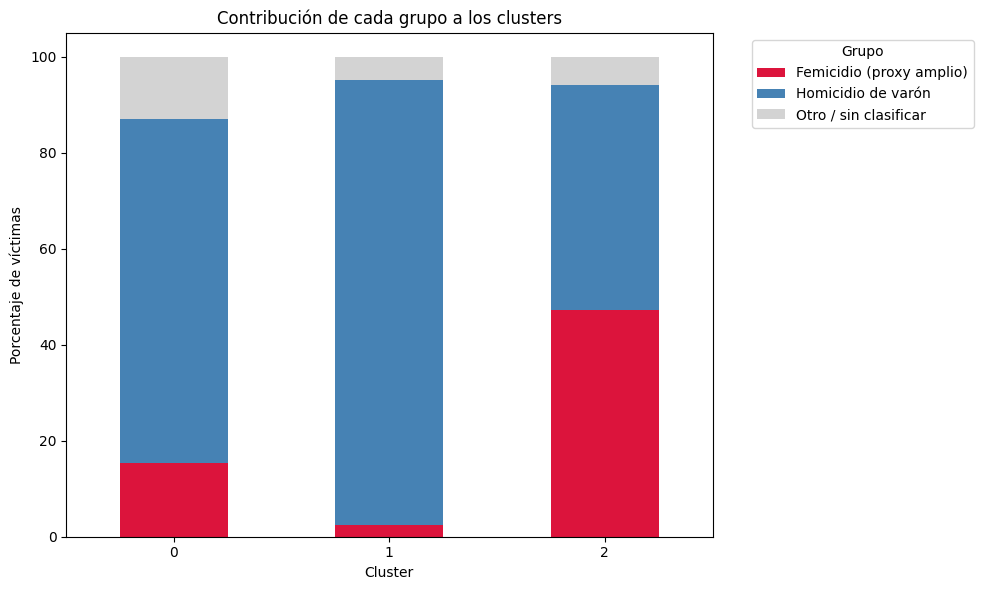

In [12]:
import matplotlib.pyplot as plt

# Calculamos la contribución porcentual de cada grupo a cada cluster
cluster_contribution = pd.crosstab(
    vic['cluster'],
    vic['grupo'],
    normalize='index'
) * 100

# Ordenamos las columnas para que "Femicidio (proxy amplio)" y "Homicidio de varón" estén primero
# si están presentes, seguido de "Otro / sin clasificar"
column_order = [
    'Femicidio (proxy amplio)',
    'Homicidio de varón',
    'Otro / sin clasificar'
]

# Filter to only include columns that exist in cluster_contribution
column_order = [col for col in column_order if col in cluster_contribution.columns]

cluster_contribution = cluster_contribution[column_order]

# Definimos los colores para cada grupo
colors = {
    'Femicidio (proxy amplio)': 'crimson',
    'Homicidio de varón': 'steelblue',
    'Otro / sin clasificar': 'lightgrey'
}

# Creamos una lista de colores en el orden de las columnas
plot_colors = [colors[col] for col in column_order]

# Graficamos la contribución de cada grupo por cluster
cluster_contribution.plot(kind='bar', stacked=True, figsize=(10, 6), color=plot_colors)

plt.title('Contribución de cada grupo a los clusters')
plt.xlabel('Cluster')
plt.ylabel('Porcentaje de víctimas')
plt.xticks(rotation=0)
plt.legend(title='Grupo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

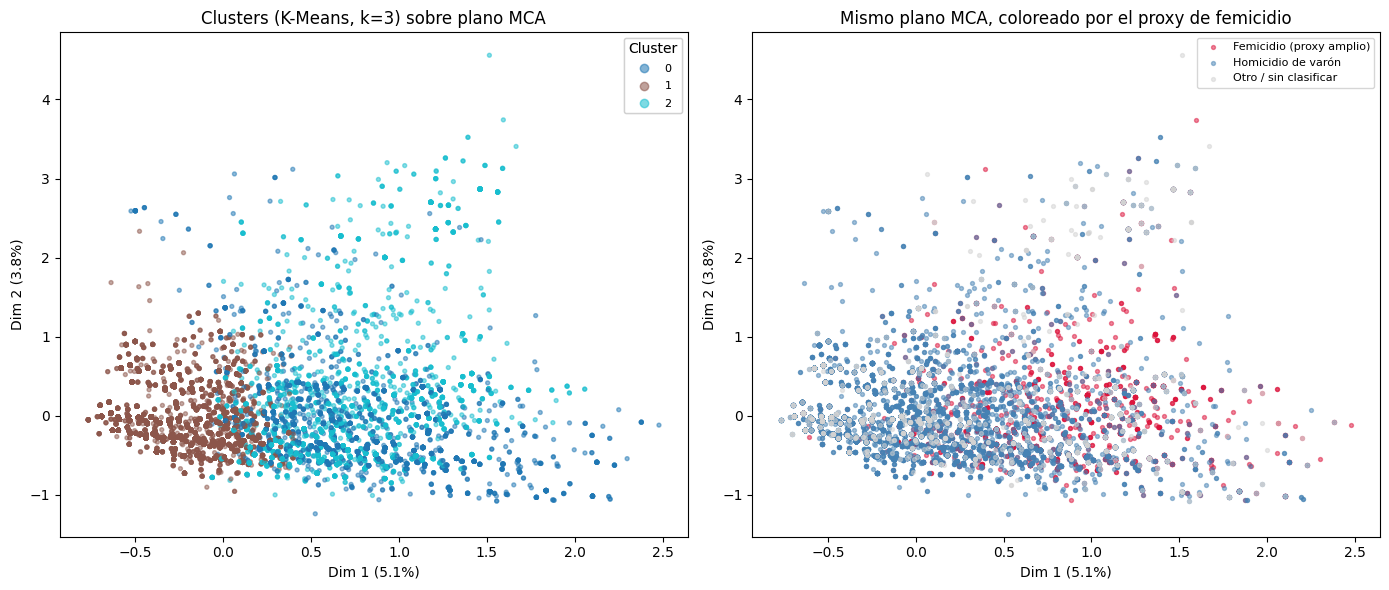

In [9]:
import matplotlib.pyplot as plt
import os

# Visualización de los clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Clusters (K-Means) sobre plano MCA
scatter = axes[0].scatter(coords[0], coords[1], c=vic['cluster'], cmap='tab10', s=8, alpha=0.5)
axes[0].set_title(f'Clusters (K-Means, k={mejor_k}) sobre plano MCA')
axes[0].set_xlabel(f'Dim 1 ({mca.percentage_of_variance_[0]:.1f}%)')
axes[0].set_ylabel(f'Dim 2 ({mca.percentage_of_variance_[1]:.1f}%)')
legend1 = axes[0].legend(*scatter.legend_elements(), title="Cluster", loc='best', fontsize=8)
axes[0].add_artist(legend1)

# Define colors for the groups
colores_grupo = {
    'Femicidio (proxy amplio)': 'crimson',
    'Homicidio de varón': 'steelblue',
    'Otro / sin clasificar': 'lightgrey',
}

# Plot 2: Mismo plano MCA, coloreado por el proxy de femicidio
for grupo, color in colores_grupo.items():
    mask = vic['grupo'] == grupo
    axes[1].scatter(coords.loc[mask, 0], coords.loc[mask, 1], c=color, s=8, alpha=0.5, label=grupo)
axes[1].set_title('Mismo plano MCA, coloreado por el proxy de femicidio')
axes[1].set_xlabel(f'Dim 1 ({mca.percentage_of_variance_[0]:.1f}%)')
axes[1].set_ylabel(f'Dim 2 ({mca.percentage_of_variance_[1]:.1f}%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ARBOL DE CLASIFICACIÓN (SUPERVISADO)
¿se puede distinguir un femicidio de un
homicidio de varón usando las circunstancias del hecho (arma,
lugar, provincia, mes, edad, origen del registro)?


In [ ]:
# Instalamos librerías necesarias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)

plt.rcParams['figure.dpi'] = 110
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# 1. Preparamos variables necesarias, se excluyen
#- 'victima_relacion_inculpado' (vínculo): Incluirla haría que el árbol "memorice la regla" en vez de aprender un patrón.
#- 'victima_sexo': Incluir sexo sería predecir la etiqueta con la etiqueta.
#- 'tipo_hecho_segun_victima': es literalmente la columna de la que se deriva la etiqueta 'grupo'.

def tramo_a_num(t):
    if pd.isna(t) or 'Sin' in str(t):
        return np.nan
    if '4 o menos' in t:
        return 2
    if 'más' in t:
        return 92
    try:
        a, b = t.split('-')
        return (int(a) + int(b)) / 2
    except Exception:
        return np.nan

comp['edad_num'] = comp['victima_tr_edad'].apply(tramo_a_num)
comp['edad_num'] = comp['edad_num'].fillna(comp['edad_num'].median())

FEATURES_CATEGORICAS = ['clase_arma', 'tipo_lugar', 'provincia_nombre', 'motivo_origen_registro']
FEATURES_NUMERICAS = ['mes', 'edad_num']

X = comp[FEATURES_CATEGORICAS + FEATURES_NUMERICAS]
y = comp['grupo']

In [ ]:
# 2. TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} casos | Test: {len(X_test)} casos")


Train: 12190 casos | Test: 4064 casos


In [ ]:
# 3. PIPELINE: one-hot encoding para categóricas + árbol de decisión
# ======================================================================
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CATEGORICAS),
    ],
    remainder='passthrough'  # deja pasar las numéricas (mes, edad_num) tal cual
)

modelo = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('arbol', DecisionTreeClassifier(
        max_depth=4,                 # profundidad chica: prioriza interpretabilidad
        class_weight='balanced',     # compensa el desbalance 14.202 vs 2.052
        random_state=42,
    )),
])

modelo.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocesador',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['clase_arma', 'tipo_lugar',
                                                   'provincia_nombre',
                                                   'motivo_origen_registro'])])),
                ('arbol',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                                        random_state=42))])

In [ ]:
# 4. EVALUACIÓN
# ======================================================================
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, list(modelo.classes_).index('Femicidio (proxy amplio)')]

print("\n=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred))

auc = roc_auc_score((y_test == 'Femicidio (proxy amplio)').astype(int), y_proba)
print(f"AUC-ROC: {auc:.3f}")

f1_femicidio = f1_score(y_test, y_pred, pos_label='Femicidio (proxy amplio)')
print(f"F1-score (clase Femicidio): {f1_femicidio:.3f}")

# --- Matriz de confusión ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=ax, cmap='Blues', colorbar=False, xticks_rotation=20
)
ax.set_title('Matriz de confusión')
plt.tight_layout()
plt.close()

# --- Curva ROC ---
fpr, tpr, _ = roc_curve((y_test == 'Femicidio (proxy amplio)').astype(int), y_proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f'Árbol de decisión (AUC={auc:.3f})', color='crimson')
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Azar (AUC=0.5)')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC — predicción de "Femicidio (proxy amplio)"')
ax.legend()
plt.tight_layout()
plt.close()


=== Reporte de clasificación ===
                          precision    recall  f1-score   support

Femicidio (proxy amplio)       0.29      0.75      0.41       513
      Homicidio de varón       0.95      0.73      0.83      3551

                accuracy                           0.73      4064
               macro avg       0.62      0.74      0.62      4064
            weighted avg       0.87      0.73      0.77      4064

AUC-ROC: 0.788
F1-score (clase Femicidio): 0.413



=== Top 15 variables más importantes ===
                              variable  importancia
           cat__tipo_lugar_Vía pública     0.638183
         cat__clase_arma_Arma de fuego     0.104559
  cat__tipo_lugar_Domicilio particular     0.098993
cat__clase_arma_Ahorcamiento / asfixia     0.088941
           cat__clase_arma_Arma blanca     0.042104
                   remainder__edad_num     0.010465
         cat__provincia_nombre_Córdoba     0.009194
    cat__provincia_nombre_Buenos Aires     0.005287
         cat__provincia_nombre_Tucumán     0.001147
        cat__provincia_nombre_San Luis     0.001127
 cat__clase_arma_Otra arma o mecanismo     0.000000
cat__clase_arma_Precipitación al vacío     0.000000
        cat__clase_arma_Envenenamiento     0.000000
                cat__clase_arma_Golpes     0.000000
    cat__clase_arma_Objeto contundente     0.000000


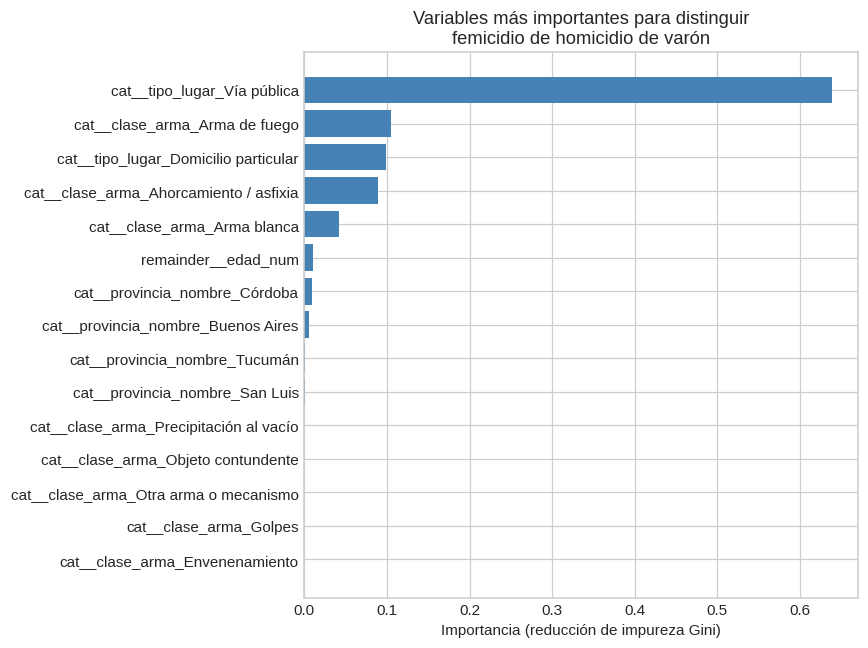

In [ ]:
#5. IMPORTANCIA DE VARIABLES
# ======================================================================
nombres_encoded = modelo.named_steps['preprocesador'].get_feature_names_out()
importancias = modelo.named_steps['arbol'].feature_importances_

df_importancias = pd.DataFrame({
    'variable': nombres_encoded,
    'importancia': importancias
}).sort_values('importancia', ascending=False)

print("\n=== Top 15 variables más importantes ===")
print(df_importancias.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top15 = df_importancias.head(15).sort_values('importancia')
ax.barh(top15['variable'], top15['importancia'], color='steelblue')
ax.set_xlabel('Importancia (reducción de impureza Gini)')
ax.set_title('Variables más importantes para distinguir\nfemicidio de homicidio de varón')
plt.tight_layout()
plt.show() # Mostrar el gráfico en lugar de cerrarlo


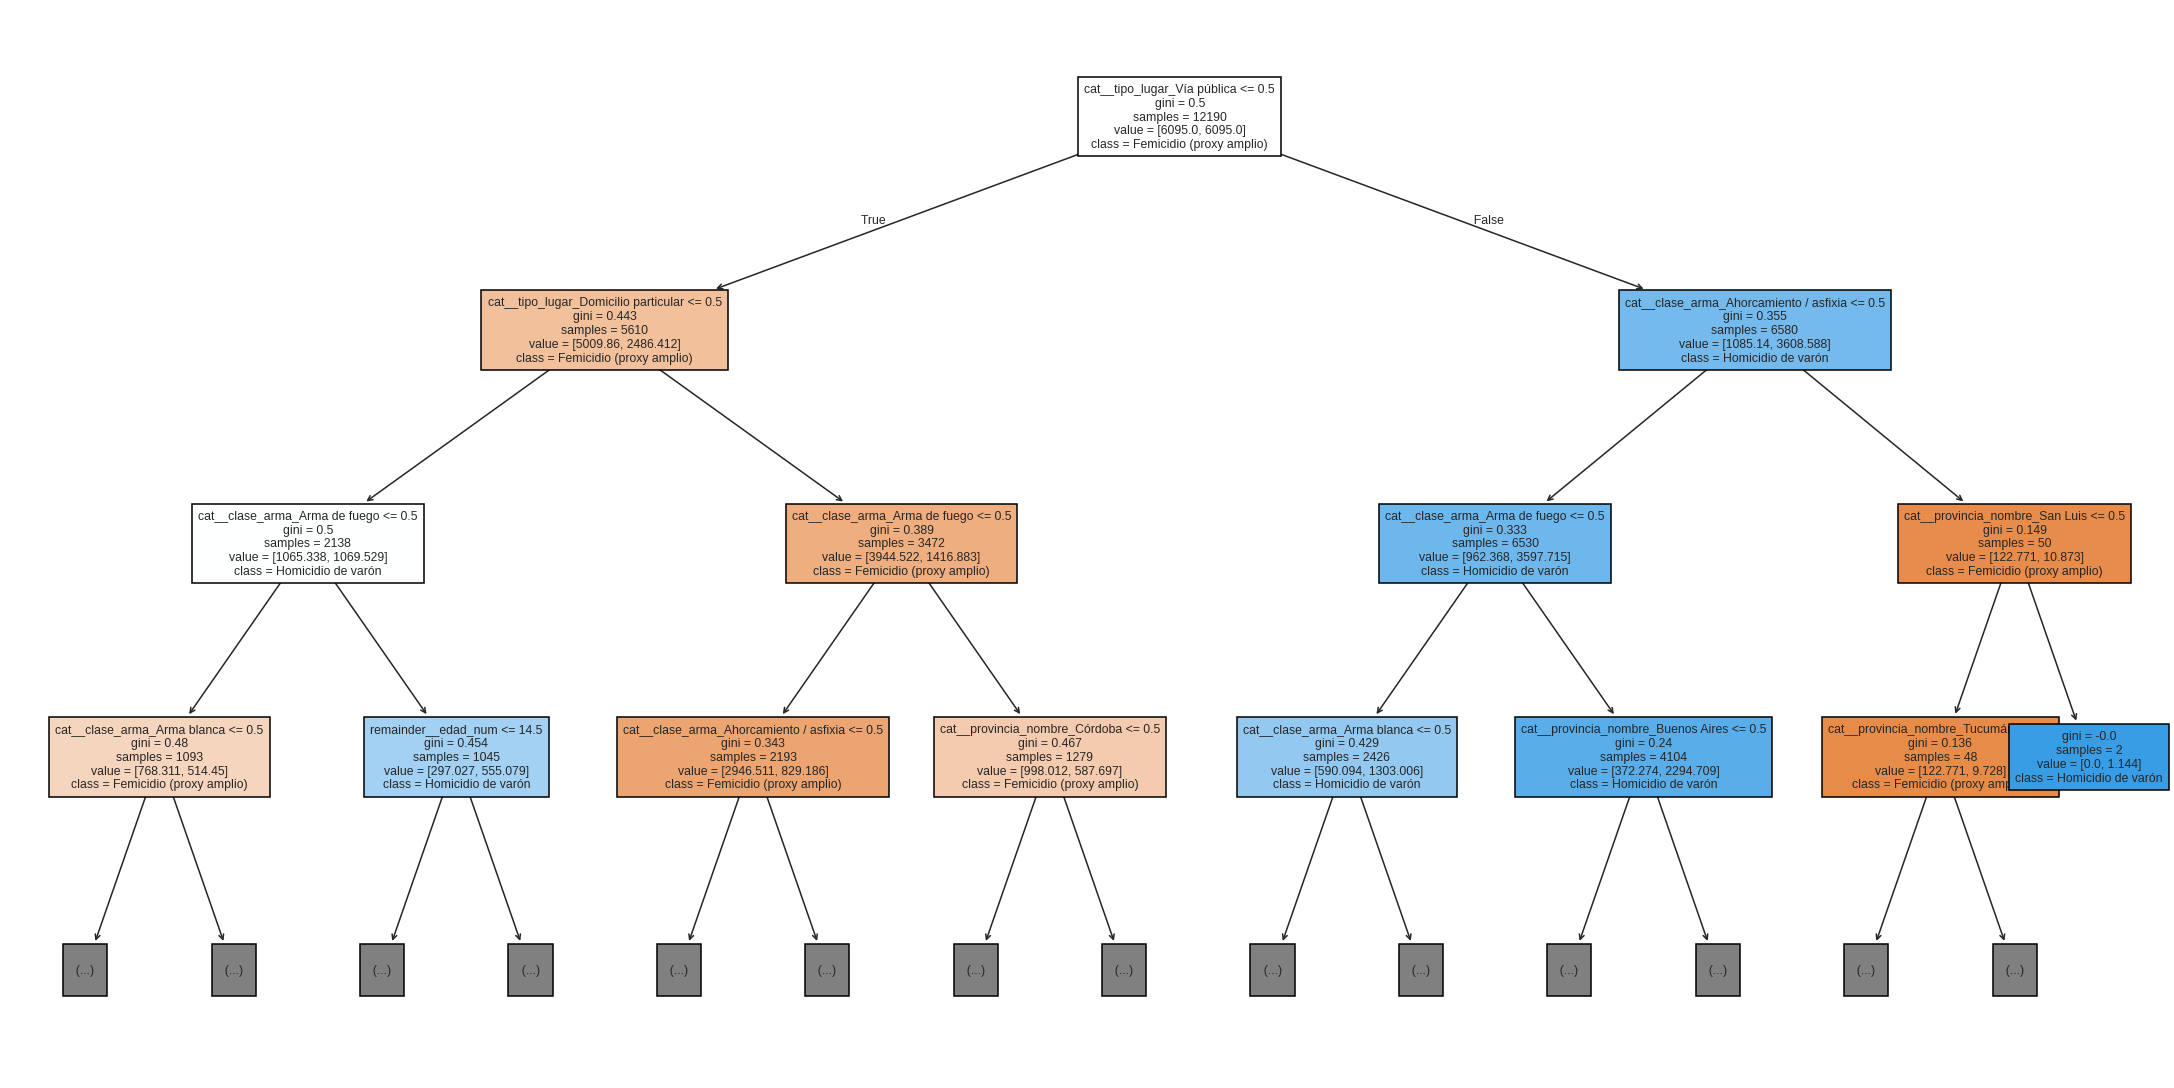


Figuras guardadas en /content/figures


In [ ]:
# 6. VISUALIZAR EL ÁRBOL (los primeros niveles, para interpretar)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    modelo.named_steps['arbol'],
    feature_names=nombres_encoded,
    class_names=modelo.classes_,
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGURAS, 'fig11_arbol.png'))
plt.show() # Mostrar el gráfico

print(f"\nFiguras guardadas en {RUTA_FIGURAS}")